In [3]:
from utils import * 
n_x = 1000
n_sim = 2000
B = 1000
portion_non_zero_weights = 0.5
var_x = 1
seed = 41
rng = np.random.default_rng(seed)

m = int(n_x * portion_non_zero_weights)         # number of non-zero weights
x_sim = rng.normal(0, var_x**0.5, (n_sim, n_x)) # simulate n_sim data-sets
weights = np.zeros(n_x)
weights[:m] = 1 / m                             # weights for the first m variables = 1/m , else 0



T_N_b, N_bi, boot_indices = bagging_mean_estimators(x=x_sim[0], B=B, seed=seed ,weights=weights)

In [2]:
boot_indices

array([[477, 383,  62, ..., 377, 409,  11],
       [266, 373,  53, ..., 114, 396,  55],
       [300, 409, 266, ..., 123,   5, 216],
       ...,
       [417, 199, 346, ..., 253,  40, 309],
       [123, 478, 179, ..., 104,  43, 354],
       [105, 335,  24, ..., 155, 357,   4]])

In [4]:

B, n_samples = N_bi.shape
theta = T_N_b.mean()


# Prepare a boolean mask for each sample's presence in each estimator's bootstrap
presence_mask = np.zeros((n_samples, B), dtype=bool)
for i, samples in enumerate(boot_indices):
    samples = np.array(samples, dtype=int)
    presence_mask[samples, i] = True

theta_is = []
for ii in range(n_samples):
    indices_without_ii = np.where(~presence_mask[ii])[0]
    if 0 < len(indices_without_ii) < B:
        theta_is.append(T_N_b[indices_without_ii].mean())

theta_is = np.array(theta_is)
var_jka_biased = np.sum((theta_is - theta) ** 2) * (n_samples - 1) / n_samples

var_jka_correction = (
(np.exp(1) - 1)
* (n_samples / B)
* np.var(T_N_b, ddof=1)
)

var_jka_biased, var_jka_correction

(0.0052899182773091065, 0.001661873641219839)

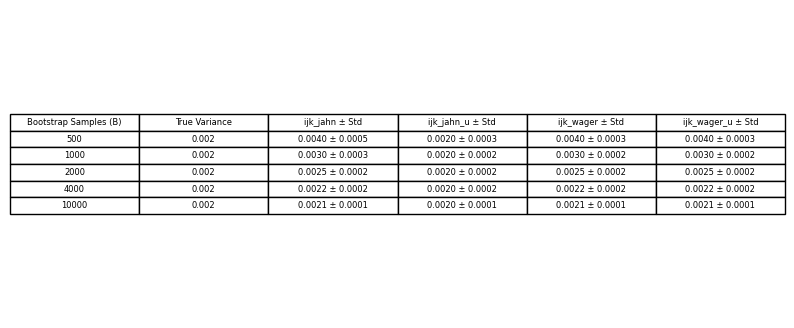

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
path = r'C:\Users\rehan\meine_Repos\Masterarbeit\Chapter 2.5.3__Figure2.11__Table2.1\Table_2.1\results.csv'

data = pd.read_csv(path)

# Bildgröße festlegen
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Tabelle zeichnen
table = ax.table(cellText=data.values,
                 colLabels=data.columns,
                 cellLoc='center',
                 loc='center')

# Tabelle als Bild speichern
image_path = "table_image.png"
plt.savefig(image_path, dpi=300, bbox_inches='tight')
plt.show()
